In [2]:
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as utils;
import pandas as pd;
import os;
import glob;

# Styling.
plt.style.use("ggplot");

In [3]:
def parameter_scan_analysis_phi2D(base_directory, folder_prefix):

	# `folder_prefix` should be of the form "DN_*_*_[parameter value]" (DN is the standard GYSELA format, not necessarily invoked here).
	search_pattern = os.path.join(base_directory, f"{folder_prefix}_*");
	# Match search pattern, return list in ascending order.
	matching_directories = sorted(glob.glob(search_pattern));

	if not matching_directories:

		print(f"No directories found matching pattern: {search_pattern}");
		return;
	
	# Wrap in pandas dataframe later.
	results = [];

	for directory in matching_directories:

		folder_basename = os.path.basename(directory);
		# Split the folder name, taking the last entry as that corresponding to the parameter value.
		parameter_value_string = folder_basename.split("_")[-1];
		parameter_value = float(parameter_value_string);
		print(f"Processing {folder_basename} with parameter value: {parameter_value}");
	
		# Load phi2D data.
		phi2D_list = reader.compile_data_from_directory("Phirth_n0", f"{directory}/sp0/Phi2D");
		time_step = reader.fetch_data_from_h5(f"{directory}/sp0/Phi2D/Phi2D_d00000.h5")["deltat"].values;
	
		# Process Phi2D data.
		gam_frequency = utils.extract_gam_frequency(phi2D_list, time_step);
		gam_growth_rate = utils.extract_gam_growth_rate(phi2D_list);
	
		# Store results as a table.
		results.append({
			"parameter_value": parameter_value,
			"gam_frequency": gam_frequency,
			"gam_growth_rate": gam_growth_rate,
			"folder_name": folder_basename
		});

	dataframe_results = pd.DataFrame(results).sort_values(by = "parameter_value");
	return dataframe_results;


In [16]:
BASE_PATH = "/zhisongqu_data/seth/GYSELA/raw/GG2019_culham_kappascan"
PREFIX = "DN_KAPPASCAN_CULHAM_Q1.5"

df = parameter_scan_analysis_phi2D(BASE_PATH, PREFIX)

if df is not None:
    print(df)

Processing DN_KAPPASCAN_CULHAM_Q1.5_1.0 with parameter value: 1.0
Processing DN_KAPPASCAN_CULHAM_Q1.5_1.1 with parameter value: 1.1
Processing DN_KAPPASCAN_CULHAM_Q1.5_1.2 with parameter value: 1.2
Processing DN_KAPPASCAN_CULHAM_Q1.5_1.3 with parameter value: 1.3
Processing DN_KAPPASCAN_CULHAM_Q1.5_1.4 with parameter value: 1.4
Processing DN_KAPPASCAN_CULHAM_Q1.5_1.5 with parameter value: 1.5
Processing DN_KAPPASCAN_CULHAM_Q1.5_1.6 with parameter value: 1.6
   parameter_value  gam_frequency  gam_growth_rate  \
0              1.0     832.031166     -7474.979479   
1              1.1     807.797249    -10449.769162   
2              1.2     775.485359    -14810.527637   
3              1.3     759.329414    -17132.014255   
4              1.4     735.095497    -36173.162357   
5              1.5     718.939552    -44840.700488   
6              1.6     694.705634    -64425.643200   

                    folder_name  
0  DN_KAPPASCAN_CULHAM_Q1.5_1.0  
1  DN_KAPPASCAN_CULHAM_Q1.5_1.1  
2  

<>:20: SyntaxWarning: invalid escape sequence '\g'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\k'
<>:20: SyntaxWarning: invalid escape sequence '\g'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_3768999/3031914185.py:20: SyntaxWarning: invalid escape sequence '\g'
  ax2.set_ylabel('$-\gamma [ms^{-1}]$', color=color_damp, fontsize=12)
/tmp/ipykernel_3768999/3031914185.py:33: SyntaxWarning: invalid escape sequence '\d'
  plt.title(f'GAM characteristics vs. {param_label}, $q = 1.5, \delta = 0$',
/tmp/ipykernel_3768999/3031914185.py:39: SyntaxWarning: invalid escape sequence '\k'
  plot_parameter_scan_results(df, param_label="$\kappa$")


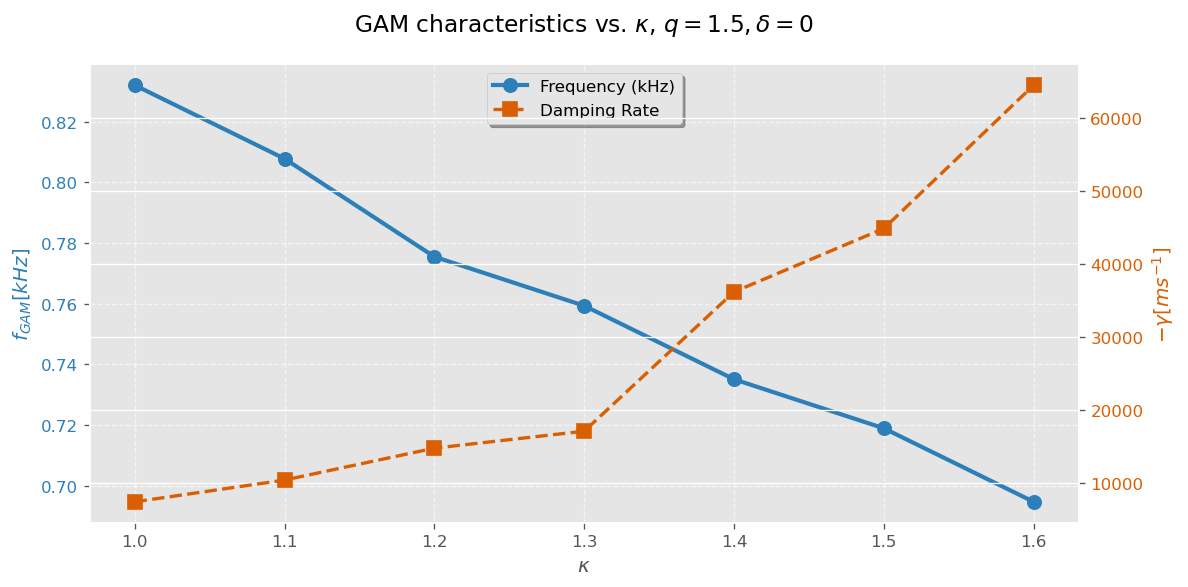

In [ ]:
# Placeholder logic for the most part.
def plot_parameter_scan_results(df, param_label):

	fig, ax1 = plt.subplots(figsize=(10, 5), dpi=120)

	# --- Axis 1: GAM Frequency ---
	color_freq = '#2c7fb8' # Deep Blue
	ax1.set_xlabel(param_label, fontsize=12, fontweight='bold')
	ax1.set_ylabel('$f_{GAM} [kHz]$', color=color_freq, fontsize=12)
	
	# Plotting line + points
	line1 = ax1.plot(df['parameter_value'], df['gam_frequency'] / 1000, 
					marker='o', markersize=8, color=color_freq, 
					linewidth=2.5, label='Frequency (kHz)')
	ax1.tick_params(axis='y', labelcolor=color_freq)
	ax1.grid(True, linestyle='--', alpha=0.6)

	# --- Axis 2: Damping Rate (Secondary) ---
	ax2 = ax1.twinx()
	color_damp = '#d95f02' # Burnt Orange
	ax2.set_ylabel('$-\gamma [ms^{-1}]$', color=color_damp, fontsize=12)
	
	# We plot the absolute value of gamma as it's conventionally shown as a positive 'rate'
	line2 = ax2.plot(df['parameter_value'], np.abs(df['gam_growth_rate']), 
					marker='s', markersize=8, color=color_damp, 
					linestyle='--', linewidth=2, label='Damping Rate')
	ax2.tick_params(axis='y', labelcolor=color_damp)

	# Adding a unified legend
	lines = line1 + line2
	labels = [l.get_label() for l in lines]
	ax1.legend(lines, labels, loc='upper center', frameon=True, shadow=True)

	plt.title(f'GAM characteristics vs. {param_label}, $q = 1.5, \delta = 0$', 
			fontsize=14, pad=20)
	
	fig.tight_layout()
	plt.show()

plot_parameter_scan_results(df, param_label="$\kappa$")
